<a href="https://colab.research.google.com/github/marcolari06-maker/loan-default-prediction/blob/main/Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Acquiring

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import sklearn

github_csv_url = 'https://raw.githubusercontent.com/marcolari06-maker/loan-default-prediction/refs/heads/main/dataset.csv'

try:
    df_github = pd.read_csv(github_csv_url)
    print("Dataset loaded from github repo loan-default-prediction")
    display(df_github.head())
    print(df_github.shape[0])
except Exception as e:
    print(f"Error during loading from github: {e}")

Dataset loaded from github repo loan-default-prediction


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


148670


# Preprocessing

In this preliminar phase we modify directly the dataset to remove/changes features, where it wouldn't result in data leakage.

The operations applied are:

*   Removal of ID since is useless
*   Removal of year, all values are the same
*   Removal of Upfront charges (Data leakage)
*   Removal of Interest rate spread (Data leakage)
*   Removal of rate of interest (Data leakage)
*   Removal of Property value and LTV, both have the negative class that is too precise and removing the records would result in the loss of too many negative record, hence the column will be removed
*   Adding of unknown class to Loan limit
*   Removal of records with null values for Age, Submission of application, Loan purpose, Neg ammortization, Term
*   Check for duplicate rows
*   Redundancies addressing



In [ ]:
# REMOVAL OF FEATURES
columns_to_drop = ['Upfront_charges', 'rate_of_interest', 'Interest_rate_spread'
                  , 'property_value', 'LTV', 'ID', 'year']

for col in columns_to_drop:
    if col in df_github.columns:
        df_github = df_github.drop(columns=[col])
        print(f"Column '{col}' dropped successfully.")
    else:
        print(f"Column '{col}' not found in the DataFrame. Skipping.")

# INSERTING UNKNOWN CLASS IN LOAN LIMIT
df_github['loan_limit'] = df_github['loan_limit'].fillna('Non_definito')
print("Loan limit after the operation")
print(df_github['loan_limit'].value_counts(dropna=False))

#REMOVAL OF RECORDS WITH NULL VALUES
interested_features = ['age', 'submission_of_application', 'loan_purpose', 'Neg_ammortization', 'term']
rows = df_github.shape[0]

for feat in interested_features:
    if feat in df_github.columns:
        df_github.dropna(subset=[feat], inplace=True)
        print(f"Rows dropped for {feat}: {rows - df_github.shape[0]}")
        rows = df_github.shape[0]
    else:
        print(f"Column '{feat}' not found. Skipping operation.")

# CHECK FOR DUPLICATE ROWS
duplicate_rows = df_github.duplicated().sum()

if duplicate_rows > 0:
    print(f"Number of duplicate rows found: {duplicate_rows}")
    # Optionally, display the duplicate rows
    # display(df_github[df_github.duplicated(keep=False)]) # keep=False shows all occurrences of duplicates
else:
    print("No duplicate rows found in the DataFrame.")

#REDUNDANCIES ADDRESSING
columns_to_remove = ['construction_type', 'Security_Type']

for col in columns_to_remove:
    if col in df_github.columns:
        df_github = df_github.drop(columns=[col])
        print(f"Column '{col}' removed successfully.")
    else:
        print(f"Column '{col}' not found in the DataFrame. Skipping.")

missing = df_github.isnull().sum()
missing_pct = (missing / len(df_github) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

# Mostra solo le colonne che hanno almeno 1 NaN
print(missing_df[missing_df['Missing Values'] > 0])

Column 'Upfront_charges' dropped successfully.
Column 'Upfront_charges' not found in the DataFrame. Skipping.
Column 'rate_of_interest' dropped successfully.
Column 'Interest_rate_spread' dropped successfully.
Column 'property_value' dropped successfully.
Column 'LTV' dropped successfully.
Column 'ID' dropped successfully.
Column 'year' dropped successfully.
Current columns in DataFrame after dropping:
Index(['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'Credit_Worthiness', 'open_credit', 'business_or_commercial',
       'loan_amount', 'term', 'Neg_ammortization', 'interest_only',
       'lump_sum_payment', 'construction_type', 'occupancy_type', 'Secured_by',
       'total_units', 'income', 'credit_type', 'Credit_Score',
       'co-applicant_credit_type', 'age', 'submission_of_application',
       'Region', 'Security_Type', 'Status', 'dtir1'],
      dtype='object')
Number of rows after dropping nulls in 'age': 148470
Rows dropped: 200
Missing values in '

# Classification

## Initial setup

In [ ]:
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score,
    RandomizedSearchCV, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score

df = df_github.copy()
# --- feature / target ---
X = df.drop(columns=["Status"])
y = df["Status"]

num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical:", num_features)
print("Categorical:", cat_features)

# --- preprocessore colonna per colonna ---
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   #IMPUTAZIONE MEDIANA
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  #IMPUTAZIONE MODA
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)

# --- schemi di CV comuni ---
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# helper for eviting copy and paste
def nested_random_search(pipe, param_dist, n_iter=20, scoring="roc_auc"):
    rs = RandomizedSearchCV(
        pipe,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring=scoring,
        cv=inner_cv,
        n_jobs=-1,
        random_state=42,
        refit=True
    )
    nested_scores = cross_val_score(
        rs, X, y,
        cv=outer_cv,
        scoring=scoring,
        n_jobs=-1
    )
    return rs, nested_scores



Numerical: ['loan_amount', 'term', 'income', 'Credit_Score', 'dtir1']
Categorical: ['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'occupancy_type', 'Secured_by', 'total_units', 'credit_type', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region']


##K-nn

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_predict  # Aggiunto cross_val_predict
from sklearn.metrics import confusion_matrix                         # Aggiunto confusion_matrix
from sklearn.pipeline import Pipeline

# 1. CREA LA PIPELINE PER IL K-NN
pipe_knn = Pipeline([
    ("preprocess", preprocess),  # Usa lo stesso preprocessor di prima (FONDAMENTALE per K-NN)
    ("clf", KNeighborsClassifier(n_jobs=-1))
])

# 2. SPAZIO DEGLI IPERPARAMETRI PER IL RANDOM SEARCH
param_dist_knn = {
    "clf__n_neighbors": [3, 5, 7, 11, 15, 21, 31, 51], # Quanti vicini guardare
    "clf__weights":     ["uniform", "distance"],       # Come pesare i vicini
    "clf__metric":      ["euclidean", "manhattan"]     # Come calcolare la distanza
}

# 3. NESTED CROSS-VALIDATION (Valutazione Corazzata)
rs_knn, nested_scores_knn = nested_random_search(pipe_knn, param_dist_knn, n_iter=20)
print(f"KNN nested AUC: {nested_scores_knn.mean():.3f} ± {nested_scores_knn.std():.3f}")

# 4. FIT COMPLETO PER TROVARE I PARAMETRI DA CUI PARTIRE
rs_knn.fit(X, y)
best_p_knn = rs_knn.best_params_

# 5. GRID SEARCH CHIRURGICA (Esploriamo i dintorni del vincitore)
param_grid_knn = {
    "clf__n_neighbors": [
        max(1, best_p_knn["clf__n_neighbors"] - 2),
        best_p_knn["clf__n_neighbors"],
        best_p_knn["clf__n_neighbors"] + 2
    ],
    "clf__weights": [best_p_knn["clf__weights"]],
    "clf__metric":  [best_p_knn["clf__metric"]]
}

gs_knn = GridSearchCV(
    pipe_knn,
    param_grid=param_grid_knn,
    scoring="roc_auc",
    cv=inner_cv,
    n_jobs=-1
)

# 6. ALLENAMENTO FINALE E RISULTATI
gs_knn.fit(X, y)
best_knn = gs_knn.best_estimator_
print("KNN best params:", gs_knn.best_params_)

# --- NUOVE SEZIONI PER LA VALUTAZIONE DI REATEO FALSI POSITIVI E NEGATIVI ---

# 7. VALUTAZIONE ROBUSTA IN CROSS-VALIDATION (Stima non polarizzata)
# Generiamo le predizioni "out-of-fold" usando l'architettura della tua Cross-Validation esterna (outer_cv)
y_pred_cv = cross_val_predict(best_knn, X, y, cv=outer_cv, n_jobs=-1)

# Estraiamo la matrice di confusione sommata su tutti i fold
tn_cv, fp_cv, fn_cv, tp_cv = confusion_matrix(y, y_pred_cv).ravel()

fpr_cv = fp_cv / (fp_cv + tn_cv)
fnr_cv = fn_cv / (fn_cv + tp_cv)

print("\n--- Valutazione in Cross-Validation (Outer CV) ---")
print(f"Falsi Positivi Totali: {fp_cv} | Falsi Negativi Totali: {fn_cv}")
print(f"Rateo Falsi Positivi (FPR): {fpr_cv:.3%}")
print(f"Rateo Falsi Negativi (FNR): {fnr_cv:.3%}")

# 8. VALUTAZIONE SUL TRAINING SET COMPLETO (Modello finale fittato)
y_pred_final = best_knn.predict(X)
tn_f, fp_f, fn_f, tp_f = confusion_matrix(y, y_pred_final).ravel()

fpr_final = fp_f / (fp_f + tn_f)
fnr_final = fn_f / (fn_f + tp_f)

print("\n--- Valutazione sul Dataset Completo (Apprendimento finale) ---")
print(f"Rateo Falsi Positivi Finale: {fpr_final:.3%}")
print(f"Rateo Falsi Negativi Finale: {fnr_final:.3%}")

## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        random_state=42
    ))
])

#spazio piccolo, valutiamo di mettere solamente gridsearch o se possibile
# aumentare sazio di ricerca
param_dist_lr = {
    "clf__C":            [0.001, 0.01, 0.1, 1, 10, 100],
    "clf__class_weight": [None, "balanced"],
    "clf__penalty":      ["l2"],
}

# --- nested CV con RandomizedSearch ---
rs_lr, nested_scores_lr = nested_random_search(pipe_lr, param_dist_lr, n_iter=20)
print(f"LR nested AUC: {nested_scores_lr.mean():.3f} ± {nested_scores_lr.std():.3f}")

# --- GridSearch di rifinitura su tutto il dataset ---
param_grid_lr = {
    "clf__C":            [0.1, 1, 10],
    "clf__class_weight": [None, "balanced"],
}

gs_lr = GridSearchCV(
    pipe_lr,
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=inner_cv,
    n_jobs=-1
)
gs_lr.fit(X, y)
best_lr = gs_lr.best_estimator_
print("LR best params:", gs_lr.best_params_)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=20. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=20. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=20. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=20. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packa

LR nested AUC: 0.830 ± 0.002
LR best params: {'clf__C': 1, 'clf__class_weight': 'balanced'}


## Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

pipe_dt = Pipeline([
    ("preprocess", preprocess),
    ("clf", DecisionTreeClassifier(random_state=42))
])

param_dist_dt = {
    "clf__max_depth":        [3, 5, 8, 10, 15, None],
    "clf__min_samples_leaf": [1, 5, 10, 20, 50],
    "clf__criterion":        ["gini", "entropy"],
    "clf__class_weight":     [None, "balanced"],
}

rs_dt, nested_scores_dt = nested_random_search(pipe_dt, param_dist_dt, n_iter=30)
print(f"DT nested AUC: {nested_scores_dt.mean():.3f} ± {nested_scores_dt.std():.3f}")

param_grid_dt = {
    "clf__max_depth":        [3, 5, 8],
    "clf__min_samples_leaf": [5, 10, 20],
    "clf__class_weight":     [None, "balanced"],
}

gs_dt = GridSearchCV(
    pipe_dt,
    param_grid=param_grid_dt,
    scoring="roc_auc",
    cv=inner_cv,
    n_jobs=-1
)
gs_dt.fit(X, y)
best_dt = gs_dt.best_estimator_
print("DT best params:", gs_dt.best_params_)

DT nested AUC: 0.862 ± 0.002
DT best params: {'clf__class_weight': 'balanced', 'clf__max_depth': 8, 'clf__min_samples_leaf': 20}


## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

# provare ad aumentare spazio, in questo modo ci mette sui 3 minuti
param_dist_rf = {
    "clf__n_estimators":     [50, 100],
    "clf__max_depth":        [10, None],
    "clf__min_samples_leaf": [10, 20],
    "clf__max_features":     ["sqrt", "log2", 0.3],
    "clf__class_weight":     [None, "balanced"],
}

rs_rf, nested_scores_rf = nested_random_search(pipe_rf, param_dist_rf, n_iter=15)
print(f"RF nested AUC: {nested_scores_rf.mean():.3f} ± {nested_scores_rf.std():.3f}")

# usa i best params del RandomizedSearch come centro del grid
rs_rf.fit(X, y)
best_p_rf = rs_rf.best_params_

param_grid_rf = {
    "clf__n_estimators": [best_p_rf["clf__n_estimators"]],
    "clf__max_depth":    [best_p_rf["clf__max_depth"]],
    "clf__min_samples_leaf": [
        max(1, best_p_rf["clf__min_samples_leaf"] - 5),
        best_p_rf["clf__min_samples_leaf"],
        best_p_rf["clf__min_samples_leaf"] + 5
    ],
    "clf__class_weight": [best_p_rf["clf__class_weight"]],
}

gs_rf = GridSearchCV(
    pipe_rf,
    param_grid=param_grid_rf,
    scoring="roc_auc",
    cv=inner_cv,
    n_jobs=-1
)
gs_rf.fit(X, y)
best_rf = gs_rf.best_estimator_

print("RF best params:", gs_rf.best_params_)

RF nested AUC: 0.873 ± 0.001
RF best params: {'clf__class_weight': 'balanced', 'clf__max_depth': None, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 100}


Exception ignored in: <function ResourceTracker.__del__ at 0x10309dc60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1048d9c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102c01c60>
Traceback (most recent call last

## Adaboost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

pipe_ada = Pipeline([
    ("preprocess", preprocess),
    ("clf", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        random_state=42
    ))
])

#spazio piccolo, valutiamo di mettere solamente gridsearch o se possibile
# aumentare sazio di ricerca
param_dist_ada = {
    "clf__n_estimators": [50, 100, 200],
    "clf__learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
}

rs_ada, nested_scores_ada = nested_random_search(
    pipe_ada, param_dist_ada, n_iter=20
)
print(f"AdaBoost nested AUC: {nested_scores_ada.mean():.3f} ± {nested_scores_ada.std():.3f}")


rs_ada.fit(X, y)
best_p_ada = rs_ada.best_params_

param_grid_ada = {
    "clf__n_estimators": [best_p_ada["clf__n_estimators"]],
    "clf__learning_rate": [
        best_p_ada["clf__learning_rate"] / 2,
        best_p_ada["clf__learning_rate"],
        best_p_ada["clf__learning_rate"] * 2
    ]
}

gs_ada = GridSearchCV(
    pipe_ada,
    param_grid=param_grid_ada,
    scoring="roc_auc",
    cv=inner_cv,
    n_jobs=-1
)
gs_ada.fit(X, y)
best_ada = gs_ada.best_estimator_
print("GB best params:", gs_ada.best_params_)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 15 is smaller than n_iter=20. Running 15 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 15 is smaller than n_iter=20. Running 15 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 15 is smaller than n_iter=20. Running 15 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 15 is smaller than n_iter=20. Running 15 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packa

AdaBoost nested AUC: 0.842 ± 0.002


/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 15 is smaller than n_iter=20. Running 15 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


GB best params: {'clf__learning_rate': 1.0, 'clf__n_estimators': 200}


## Comparison

          model  nested_auc_mean  nested_auc_std
2  RandomForest         0.873260        0.001121
1       DecTree         0.861840        0.001639
3      AdaBoost         0.842421        0.002028
0        LogReg         0.830401        0.002406
          model  auc_mean   auc_std   f1_mean    f1_std  precision_mean  \
2  RandomForest  0.873260  0.001121  0.704253  0.003174        0.751851   
1       DecTree  0.846918  0.001516  0.681352  0.004810        0.698742   
3      AdaBoost  0.842421  0.002028  0.620584  0.006035        0.966330   
0        LogReg  0.830376  0.002402  0.634273  0.002056        0.640398   

   precision_std  recall_mean  recall_std  
2       0.002348     0.662368    0.006511  
1       0.022738     0.665798    0.016053  
3       0.009653     0.457093    0.006067  
0       0.001443     0.628283    0.004192  


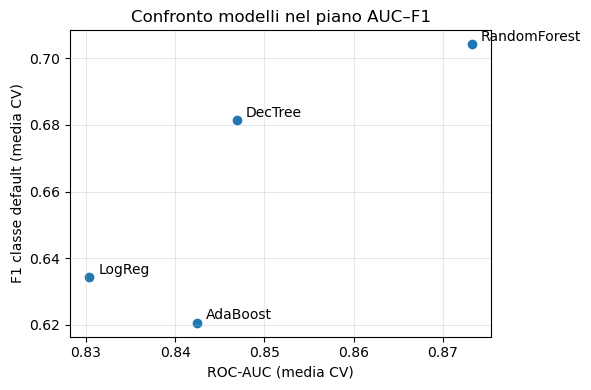

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt

summary_nested = pd.DataFrame({
    "model": ["LogReg", "DecTree", "RandomForest", "AdaBoost"],
    "nested_auc_mean": [
        nested_scores_lr.mean(),
        nested_scores_dt.mean(),
        nested_scores_rf.mean(),
        nested_scores_ada.mean()
    ],
    "nested_auc_std": [
        nested_scores_lr.std(),
        nested_scores_dt.std(),
        nested_scores_rf.std(),
        nested_scores_ada.std()
    ],
})

print(summary_nested.sort_values("nested_auc_mean", ascending=False))

models_final = [
    ("LogReg",       best_lr),
    ("DecTree",      best_dt),
    ("RandomForest", best_rf),
    ("AdaBoost",    best_ada),
]

rows = []
for name, clf in models_final:
    # AUC media in CV
    auc_scores = cross_val_score(
        clf, X, y,
        cv=outer_cv,
        scoring="roc_auc",
        n_jobs=-1
    )
    # F1 media sulla classe positiva (default=1)
    f1_scores = cross_val_score(
        clf, X, y,
        cv=outer_cv,
        scoring="f1",   # per binary {0,1} usa F1 su 1
        n_jobs=-1
    )
    # Precision media sulla classe positiva
    precision_scores = cross_val_score(
        clf, X, y,
        cv=outer_cv,
        scoring="precision",
        n_jobs=-1
    )
    # Recall media sulla classe positiva
    recall_scores = cross_val_score(
        clf, X, y,
        cv=outer_cv,
        scoring="recall",
        n_jobs=-1
    )
    rows.append({
        "model":      name,
        "auc_mean":   auc_scores.mean(),
        "auc_std":    auc_scores.std(),
        "f1_mean":    f1_scores.mean(),
        "f1_std":     f1_scores.std(),
        "precision_mean": precision_scores.mean(),
        "precision_std":  precision_scores.std(),
        "recall_mean":    recall_scores.mean(),
        "recall_std":     recall_scores.std(),
    })

df_metrics = pd.DataFrame(rows)
print(df_metrics.sort_values("auc_mean", ascending=False))

plt.figure(figsize=(6, 4))
plt.scatter(df_metrics["auc_mean"], df_metrics["f1_mean"])

for _, r in df_metrics.iterrows():
    plt.text(
        r["auc_mean"] + 0.001,
        r["f1_mean"] + 0.001,
        r["model"]
    )

plt.xlabel("ROC-AUC (media CV)")
plt.ylabel("F1 classe default (media CV)")
plt.title("Confronto modelli nel piano AUC–F1")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()